In [1]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!git clone https://github.com/Sean0418/brain-to-text-project.git

Cloning into 'brain-to-text-project'...
remote: Enumerating objects: 3518, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 3518 (delta 109), reused 112 (delta 59), pack-reused 3345 (from 2)
Receiving objects: 100% (3518/3518), 82.39 MiB | 57.32 MiB/s, done.
Resolving deltas: 100% (742/742), done.


In [5]:
!git checkout work_on_pretrained_cnn

Branch 'work_on_pretrained_cnn' set up to track remote branch 'work_on_pretrained_cnn' from 'origin'.
Switched to a new branch 'work_on_pretrained_cnn'


In [ ]:
# If needed, you can pull here - DO NOT re-clone
!git pull

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 285 bytes | 285.00 KiB/s, done.
From https://github.com/Sean0418/brain-to-text-project
   6832d07..e8318e4  sean       -> origin/sean
Updating 6832d07..e8318e4
Fast-forward
 requirements.txt | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


In [3]:
%cd /content/brain-to-text-project/

/content/brain-to-text-project


In [6]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of wfdb to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.5/261.5 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 111.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.3/365.3 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
from cnn_transformer_model.cnn_transformer_trainer import CNN_Transformer_Trainer

In [5]:
import torch
from omegaconf import OmegaConf

torch.set_float32_matmul_precision("high")
torch.backends.cudnn.deterministic = True
torch._dynamo.config.cache_size_limit = 64

In [6]:
# Run training
args_path = "cnn_transformer_model/pretrained_cnn_transformer.yaml"
args = OmegaConf.load(args_path)

print("Loaded config from:", args_path)

Loaded config from: cnn_transformer_model/pretrained_cnn_transformer.yaml


In [7]:
%cd /content/drive/

/content/drive


In [8]:
trainer = CNN_Transformer_Trainer(args)

2025-11-20 02:08:08,758: Using device: cpu


INFO:BrainToTextTrainer:Using device: cpu
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1`. You can also use `weights=ShuffleNet_V2_X1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the

2025-11-20 02:08:12,850: Initialized CNN transformer model


INFO:BrainToTextTrainer:Initialized CNN transformer model


2025-11-20 02:08:12,852: OptimizedModule(
  (_orig_mod): CNNTransformer(
    (cnn): ShuffleNetV2(
      (conv1): Sequential(
        (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (stage2): Sequential(
        (0): InvertedResidual(
          (branch1): Sequential(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=24, bias=False)
            (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): Conv2d(24, 58, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (3): BatchNorm2d(58, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (4): ReLU(inplace=True)
          )
          (branch2): Sequential(
        

...

INFO:BrainToTextTrainer:Frozen: _orig_mod.transformer_model.decoder.block.7.layer.2.DenseReluDense.wo.weight


2025-11-20 02:08:29,104: Frozen: _orig_mod.transformer_model.decoder.block.7.layer.2.layer_norm.weight


INFO:BrainToTextTrainer:Frozen: _orig_mod.transformer_model.decoder.block.7.layer.2.layer_norm.weight


2025-11-20 02:08:29,105: Frozen: _orig_mod.transformer_model.decoder.final_layer_norm.weight


INFO:BrainToTextTrainer:Frozen: _orig_mod.transformer_model.decoder.final_layer_norm.weight


In [9]:
for i, batch in enumerate(trainer.train_loader):

  break

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [10]:
features = batch['input_features']
n_time_steps = batch['n_time_steps']
import numpy as np

In [11]:
# data_augmentations + dataset + train/val split

import math
import os

import h5py
import numpy as np
import torch
import torch.nn.functional as F
from scipy.ndimage import gaussian_filter1d
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset


def gauss_smooth(
    inputs, device, smooth_kernel_std=2, smooth_kernel_size=100, padding="same"
):
    inp = np.zeros(smooth_kernel_size, dtype=np.float32)
    inp[smooth_kernel_size // 2] = 1
    gaussKernel = gaussian_filter1d(inp, smooth_kernel_std)
    validIdx = np.argwhere(gaussKernel > 0.01)
    gaussKernel = gaussKernel[validIdx]
    gaussKernel = np.squeeze(gaussKernel / np.sum(gaussKernel))

    gaussKernel = torch.tensor(gaussKernel, dtype=torch.float32, device=device)
    gaussKernel = gaussKernel.view(1, 1, -1)

    B, T, C = inputs.shape
    inputs = inputs.permute(0, 2, 1)
    gaussKernel = gaussKernel.repeat(C, 1, 1)

    smoothed = F.conv1d(inputs, gaussKernel, padding=padding, groups=C)
    return smoothed.permute(0, 2, 1)


class BrainToTextDataset(Dataset):
    def __init__(
        self,
        trial_indicies,
        n_batches,
        split="train",
        batch_size=64,
        days_per_batch=1,
        random_seed=-1,
        must_include_days=None,
        feature_subset=None,
    ):
        if random_seed != -1:
            np.random.seed(random_seed)
            torch.manual_seed(random_seed)

        if split not in ["train", "test"]:
            raise ValueError(f'split must be "train" or "test", got {split}')

        self.split = split
        self.days_per_batch = days_per_batch
        self.batch_size = batch_size
        self.n_batches = n_batches

        self.trial_indicies = trial_indicies
        self.n_days = len(trial_indicies.keys())
        self.feature_subset = feature_subset
        self.n_trials = sum(len(trial_indicies[d]["trials"]) for d in trial_indicies)

        if must_include_days is not None and len(must_include_days) > days_per_batch:
            raise ValueError("must_include_days must be <= days_per_batch")

        if (
            must_include_days is not None
            and len(must_include_days) > self.n_days
            and split != "train"
        ):
            raise ValueError("must_include_days not valid for test data")

        if must_include_days is not None:
            for i, d in enumerate(must_include_days):
                if d < 0:
                    must_include_days[i] = self.n_days + d

        self.must_include_days = must_include_days

        if self.split == "train" and self.days_per_batch > self.n_days:
            raise ValueError(f"days_per_batch {days_per_batch} > n_days {self.n_days}")

        if self.split == "train":
            self.batch_index = self.create_batch_index_train()
        else:
            self.batch_index = self.create_batch_index_test()
            self.n_batches = len(self.batch_index.keys())

    def __len__(self):
        return self.n_batches

    def __getitem__(self, idx):
        batch = {
            "input_features": [],
            "seq_class_ids": [],
            "n_time_steps": [],
            "phone_seq_lens": [],
            "day_indicies": [],
            "transcriptions": [],
            "block_nums": [],
            "trial_nums": [],
        }

        index = self.batch_index[idx]

        for d in index.keys():
            with h5py.File(self.trial_indicies[d]["session_path"], "r") as f:
                for t in index[d]:
                    try:
                        g = f[f"trial_{t:04d}"]

                        x = torch.from_numpy(g["input_features"][:])
                        if self.feature_subset:
                            x = x[:, self.feature_subset]

                        batch["input_features"].append(x)
                        batch["seq_class_ids"].append(
                            torch.from_numpy(g["seq_class_ids"][:])
                        )
                        batch["transcriptions"].append(
                            torch.from_numpy(g["transcription"][:])
                        )
                        batch["n_time_steps"].append(g.attrs["n_time_steps"])
                        batch["phone_seq_lens"].append(g.attrs["seq_len"])
                        batch["day_indicies"].append(int(d))
                        batch["block_nums"].append(g.attrs["block_num"])
                        batch["trial_nums"].append(g.attrs["trial_num"])
                    except Exception as e:
                        print(
                            f"Error loading trial {t} from {self.trial_indicies[d]['session_path']}: {e}"
                        )
                        continue

        batch["input_features"] = pad_sequence(
            batch["input_features"], batch_first=True, padding_value=0
        )
        batch["seq_class_ids"] = pad_sequence(
            batch["seq_class_ids"], batch_first=True, padding_value=0
        )

        batch["n_time_steps"] = torch.tensor(batch["n_time_steps"])
        batch["phone_seq_lens"] = torch.tensor(batch["phone_seq_lens"])
        batch["day_indicies"] = torch.tensor(batch["day_indicies"])
        batch["transcriptions"] = torch.stack(batch["transcriptions"])
        batch["block_nums"] = torch.tensor(batch["block_nums"])
        batch["trial_nums"] = torch.tensor(batch["trial_nums"])

        return batch

    def create_batch_index_train(self):
        batch_index = {}

        if self.must_include_days is not None:
            non_must_include_days = [
                d for d in self.trial_indicies.keys() if d not in self.must_include_days
            ]

        for batch_idx in range(self.n_batches):
            batch = {}

            if self.must_include_days is not None and len(self.must_include_days) > 0:
                days = np.concatenate(
                    (
                        self.must_include_days,
                        np.random.choice(
                            non_must_include_days,
                            size=self.days_per_batch - len(self.must_include_days),
                            replace=False,
                        ),
                    )
                )
            else:
                days = np.random.choice(
                    list(self.trial_indicies.keys()),
                    size=self.days_per_batch,
                    replace=False,
                )

            num_trials = math.ceil(self.batch_size / self.days_per_batch)

            for d in days:
                trial_idxs = np.random.choice(
                    self.trial_indicies[d]["trials"], size=num_trials, replace=True
                )
                batch[d] = trial_idxs

            extra_trials = (num_trials * len(days)) - self.batch_size
            while extra_trials > 0:
                d = np.random.choice(days)
                batch[d] = batch[d][:-1]
                extra_trials -= 1

            batch_index[batch_idx] = batch

        return batch_index

    def create_batch_index_test(self):
        batch_index = {}
        batch_idx = 0

        for d in self.trial_indicies.keys():
            num_trials = len(self.trial_indicies[d]["trials"])
            num_batches = (num_trials + self.batch_size - 1) // self.batch_size

            for i in range(num_batches):
                start_idx = i * self.batch_size
                end_idx = min((i + 1) * self.batch_size, num_trials)
                batch_trials = self.trial_indicies[d]["trials"][start_idx:end_idx]
                batch_index[batch_idx] = {d: batch_trials}
                batch_idx += 1

        return batch_index


def train_test_split_indicies(
    file_paths, test_percentage=0.1, seed=-1, bad_trials_dict=None
):
    if seed != -1:
        np.random.seed(seed)

    trials_per_day = {}
    for i, path in enumerate(file_paths):
        session = [
            s
            for s in path.split("/")
            if (s.startswith("t15.20") or s.startswith("t12.20"))
        ][0]
        good_trial_indices = []

        if os.path.exists(path):
            with h5py.File(path, "r") as f:
                num_trials = len(list(f.keys()))
                for t in range(num_trials):
                    key = f"trial_{t:04d}"
                    block_num = f[key].attrs["block_num"]
                    trial_num = f[key].attrs["trial_num"]

                    if (
                        bad_trials_dict is not None
                        and session in bad_trials_dict
                        and str(block_num) in bad_trials_dict[session]
                        and trial_num in bad_trials_dict[session][str(block_num)]
                    ):
                        continue

                    good_trial_indices.append(t)

        trials_per_day[i] = {
            "num_trials": len(good_trial_indices),
            "trial_indices": good_trial_indices,
            "session_path": path,
        }

    train_trials, test_trials = {}, {}

    for day in trials_per_day.keys():
        num_trials = trials_per_day[day]["num_trials"]
        all_trial_indices = trials_per_day[day]["trial_indices"]
        session_path = trials_per_day[day]["session_path"]

        if test_percentage == 0:
            train_trials[day] = {
                "trials": all_trial_indices,
                "session_path": session_path,
            }
            test_trials[day] = {"trials": [], "session_path": session_path}
            continue
        if test_percentage == 1:
            train_trials[day] = {"trials": [], "session_path": session_path}
            test_trials[day] = {
                "trials": all_trial_indices,
                "session_path": session_path,
            }
            continue

        num_test = max(1, int(num_trials * test_percentage))
        test_indices = np.random.choice(
            all_trial_indices, size=num_test, replace=False
        ).tolist()
        train_indices = [idx for idx in all_trial_indices if idx not in test_indices]

        train_trials[day] = {"trials": train_indices, "session_path": session_path}
        test_trials[day] = {"trials": test_indices, "session_path": session_path}

    return train_trials, test_trials


In [12]:
if trainer.transform_args["static_gain_std"] > 0:
                warp_mat = torch.tile(
                    torch.unsqueeze(torch.eye(channels, device=trainer.device), dim=0),
                    (batch_size, 1, 1),
                )
                warp_mat += (
                    torch.randn_like(warp_mat) * trainer.transform_args["static_gain_std"]
                )
                features = torch.matmul(features, warp_mat)

if trainer.transform_args["white_noise_std"] > 0:
                features += (
                    torch.randn(data_shape, device=trainer.device)
                    * trainer.transform_args["white_noise_std"]
                )

if trainer.transform_args["constant_offset_std"] > 0:
                features += (
                    torch.randn((batch_size, 1, channels), device=trainer.device)
                    * trainer.transform_args["constant_offset_std"]
                )
if trainer.transform_args["random_walk_std"] > 0:
                features += torch.cumsum(
                    torch.randn(data_shape, device=trainer.device)
                    * trainer.transform_args["random_walk_std"],
                    dim=trainer.transform_args["random_walk_axis"],
                )

if trainer.transform_args["random_cut"] > 0:
                cut = np.random.randint(0, trainer.transform_args["random_cut"])
                features = features[:, cut:, :]
                n_time_steps = n_time_steps - cut

if trainer.transform_args["smooth_data"]:
            features = gauss_smooth(
                inputs=features,
                device=trainer.device,
                smooth_kernel_std=trainer.transform_args["smooth_kernel_std"],
                smooth_kernel_size=trainer.transform_args["smooth_kernel_size"],
            )


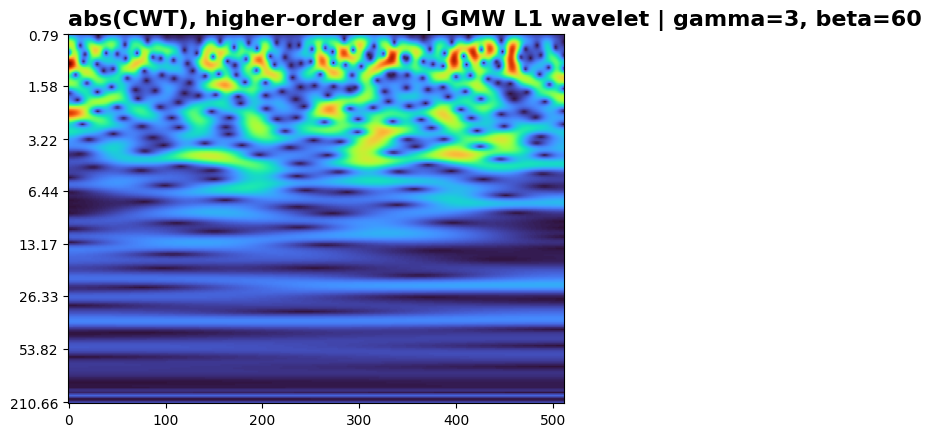

AttributeError: 'NoneType' object has no attribute 'canvas'

In [52]:
import matplotlib.pyplot as plt
import numpy as np
temp = viz_cwt_higher_order(Wx_k, scales, 'gmw')

temp.canvas.draw()

# Now we can save it to a numpy array.
data = np.frombuffer(temp.canvas.tostring_rgb(), dtype=np.uint8)
data = data.reshape(temp.canvas.get_width_height()[::-1] + (3,))


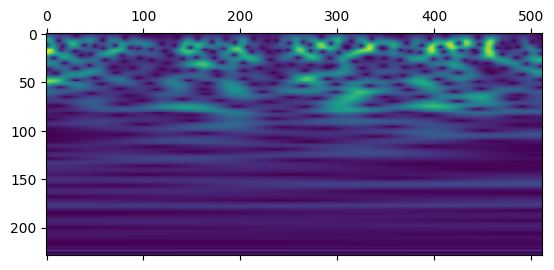

In [65]:
import matplotlib.pyplot as plt
data = Wx_k
mx = np.max(np.abs(data))
vmin, vmax = ((-mx, mx) if not abs else (0, mx))
_kw = dict(vmin=vmin, vmax=vmax)
fig = plt.figure()
fig.canvas.draw()

ax = plt.gca()
ax.matshow(np.abs(data), **_kw)


In [16]:
from tqdm import tqdm
from mspca import mspca
from ssqueezepy import cwt
from torchvision import transforms
from ssqueezepy.visuals import viz_cwt_higher_order

In [45]:
features2 = features.cpu().numpy()
for i in tqdm(range(features2.shape[0])):
                mymodel = mspca.MultiscalePCA()
                pca_temp = mymodel.fit_transform(
                    features2[i, :, :], wavelet_func="db4"
                )
                pca_temp = pca_temp.mean(0)
                Wx_k, scales = cwt(pca_temp, 'gmw')
                break

  0%|          | 0/32 [00:03<?, ?it/s]


In [49]:
features2 = features.cpu().numpy()
for i in tqdm(range(features2.shape[0])):
                mymodel = mspca.MultiscalePCA()
                pca_temp = mymodel.fit_transform(
                    features2[i, :, :], wavelet_func="db4"
                )
                pca_temp = pca_temp.mean(0)
                Wx_k, scales = cwt(pca_temp, "gmw")
                # save to a new array with (batch, features, time)
                if i == 0:
                    temporary_data = np.zeros(
                        (features.shape[0], Wx_k.shape[0], Wx_k.shape[1]),
                        dtype=np.float32,
                    )
                    temporary_data[i, :, :] = Wx_k
                else:
                    temporary_data[i, :, :] = Wx_k


  0%|          | 0/32 [00:00<?, ?it/s]/tmp/ipython-input-723491621.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  temporary_data[i, :, :] = Wx_k
  3%|▎         | 1/32 [00:01<00:50,  1.62s/it]/tmp/ipython-input-723491621.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  temporary_data[i, :, :] = Wx_k
  6%|▋         | 2/32 [00:02<00:43,  1.44s/it]/tmp/ipython-input-723491621.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  temporary_data[i, :, :] = Wx_k
  9%|▉         | 3/32 [00:04<00:40,  1.41s/it]/tmp/ipython-input-723491621.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  temporary_data[i, :, :] = Wx_k
 12%|█▎        | 4/32 [00:05<00:38,  1.38s/it]/tmp/ipython-input-723491621.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  temporary_data[i, :, :] = Wx_k
 16%|█▌        | 5/32 [00:06<00:36,  1.35s/it]/tmp/ipython

In [51]:
            features = temporary_data
            features = torch.tensor(features, device=trainer.device)

            preprocess = transforms.Compose(
                [
                    transforms.Resize(256),
                    transforms.CenterCrop(224),
                    transforms.ToTensor(),
                    transforms.Normalize(
                        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                    ),
                ]
            )
            features = preprocess(features)

TypeError: pic should be PIL Image or ndarray. Got <class 'torch.Tensor'>